In [12]:
# from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from configurations import load_data, make_params_dict, set_font_sizes, create_fig , apply_general_styles
from binary_dimension import select_range, initial_gauss, LinearDistanceModel, DKL_Optimizer
import numpy as np
import matplotlib.pyplot as plt 
import time

apply_general_styles()

In [46]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 2
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
# temps = [0.6,0.9,1.2,1.5]
# Ns = [1024,2048,4096]
temps = np.linspace(0.4,1.6,25)#[::3]
Ns = np.logspace(9,15,7,base=2).astype(int)[2:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']

data = {}
for T in temps:
    data[T] = {'av':[], 'std':[]}
    for N in Ns:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('bid_parms',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        bid_pars = dic['bid_pars']
        sigmas = dic['sigmas']
        results = np.column_stack((bid_pars, sigmas))
        m = results.mean(axis=0)
        s = results.std(axis=0)
        m[0] /= N  # normalize by N
        s[0] /= N  # normalize by N
        data[T]['av'].append(m)
        data[T]['std'].append(s)
    data[T]['av'] = np.array(data[T]['av'])
    data[T]['std'] = np.array(data[T]['std'])

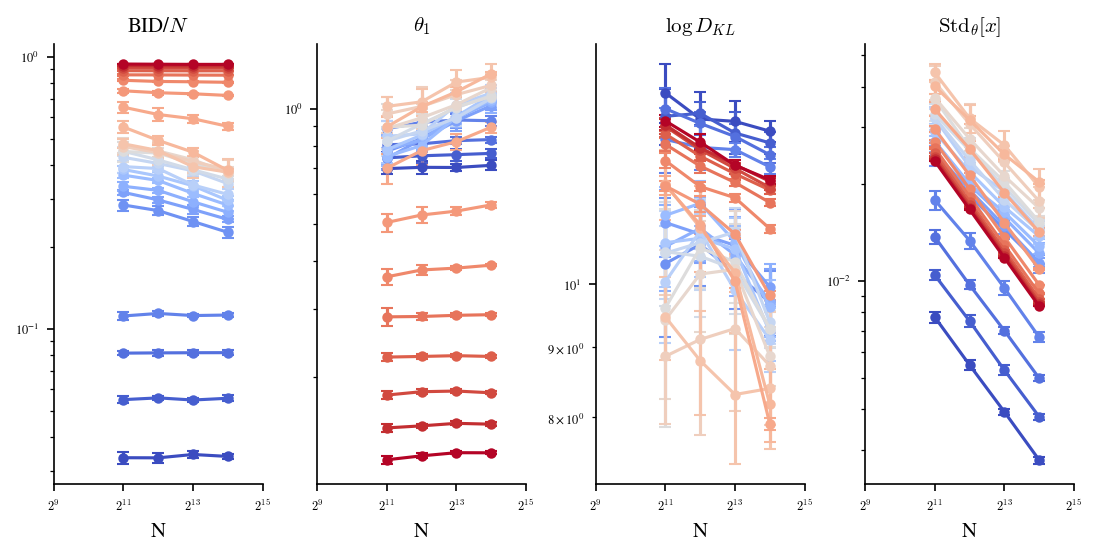

In [47]:
# Settings
set_font_sizes('tight')
titles = [r'BID/$N$',r'$\theta_1$',r'$\log D_{KL}$',r'$\text{Std}_\theta[x]$']
xtk = [2**k  for k in range(9,16,2)]
xlb = [fr'$2^{{{k}}}$' for k in range(9,16,2)]
colors = plt.get_cmap('coolwarm')(np.linspace(0,1,len(temps)))
# Create figure
fig , axes = create_fig(1,4,size='double')

for i , ax in enumerate(axes):
    for iT, T in enumerate(temps):
        av = np.abs(data[T]['av'][:,i])
        std = data[T]['std'][:,i]
        ax.errorbar(Ns, av, yerr=std, color=colors[iT], capsize=3, marker='o', markersize=4, linestyle='-')
    ax.set_xscale('log', base=2)
    ax.set_xlim(left=xtk[0])
    ax.set_yscale('log')
    ax.set_xlabel('N')
    ax.set_title(titles[i])
    ax.set_xticks(xtk,xlb)


In [48]:
def linear_regression_errors(x,y,sigmas):
    N = len(x)
    X = np.vstack([x,np.ones_like(x)]).T
    W = np.eye(N)/sigmas**2

    cov = np.linalg.inv(X.T@W@X)
    opt = cov@X.T@W@y
    return opt , np.sqrt(np.diag(cov))

# m = av_bid[iT,:,0]/Ns
# s = st_bid[iT,:,0]/Ns
# a1 , b1 = (linear_regression_errors(np.log(Ns),np.log(m),s/m))

In [49]:
mean_gammas = [[],[]]
std_gammas = [[],[]]
for T in temps:
    for i , idx in enumerate([0,3]):
        m = data[T]['av'][:,idx]
        s = data[T]['std'][:,idx]
        a1 , b1 = (linear_regression_errors(np.log(Ns),np.log(m),s/m))
        # Store mean and std of scaling exponent
        mean_gammas[i].append(-a1[0])
        std_gammas[i].append(b1[0])
mean_gammas = np.array(mean_gammas)
std_gammas = np.array(std_gammas)
print(mean_gammas.shape)
print(std_gammas.shape)    

(2, 25)
(2, 25)


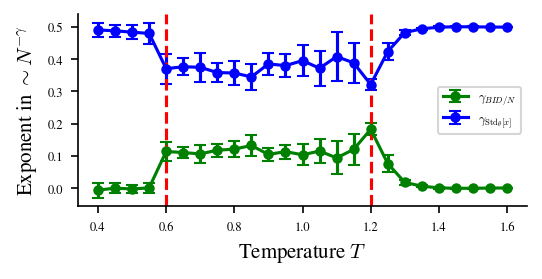

In [55]:
# Settings
set_font_sizes('tight')
labels = [r'$\gamma_{BID/N}$',r'$\gamma_{\text{Std}_\theta[x]}$']
colors = ['green','blue']
# Create figure
fig , axes = create_fig(1,1,size='single')
ax = axes
for i , lb in enumerate(labels):
    ax.errorbar(temps, mean_gammas[i], yerr=std_gammas[i], color=colors[i], capsize=3, marker='o', markersize=4, linestyle='-',label=lb)
    # ax.plot(temps,std_gammas[i], color=colors[i], marker='o', markersize=4, linestyle='-',label=lb)
    ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'Exponent in $\sim N^{-\gamma}$')
ax.legend()
ax.axvline(0.6,color='red',linestyle='--',label='Critical Temperature')
ax.axvline(1.2,color='red',linestyle='--',label='Critical Temperature')